# Iris Flower Classification — End-to-End Machine Learning

Complete workflow: load Seaborn Iris dataset → EDA → cleaning checks → X/y → train-test split → scaling → Logistic Regression, KNN, Decision Tree, Random Forest, SVM → comparison → confusion matrix → classification report → feature importance → new flower prediction.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()
print("\nStatistics:")
display(df.describe())

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Missing values:", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:", df["species"].value_counts())

Missing values: sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 1

Target distribution: species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


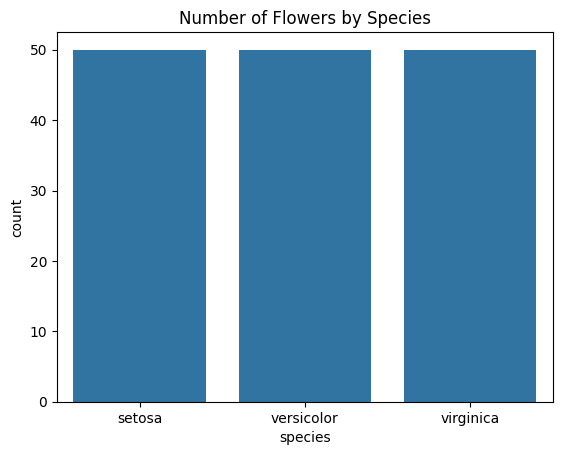

In [6]:
sns.countplot(data=df, x="species")
plt.title("Number of Flowers by Species")
plt.show()

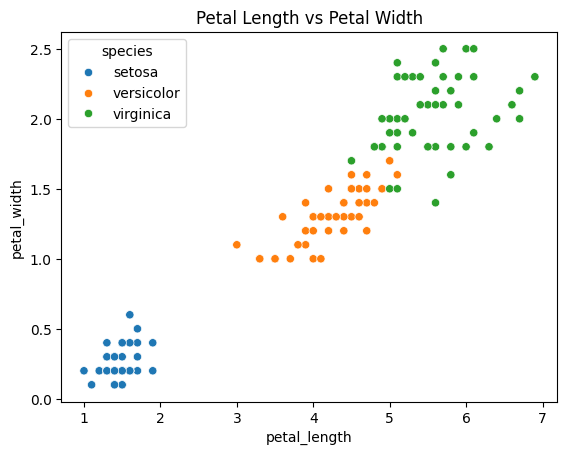

In [7]:
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Petal Length vs Petal Width")
plt.show()

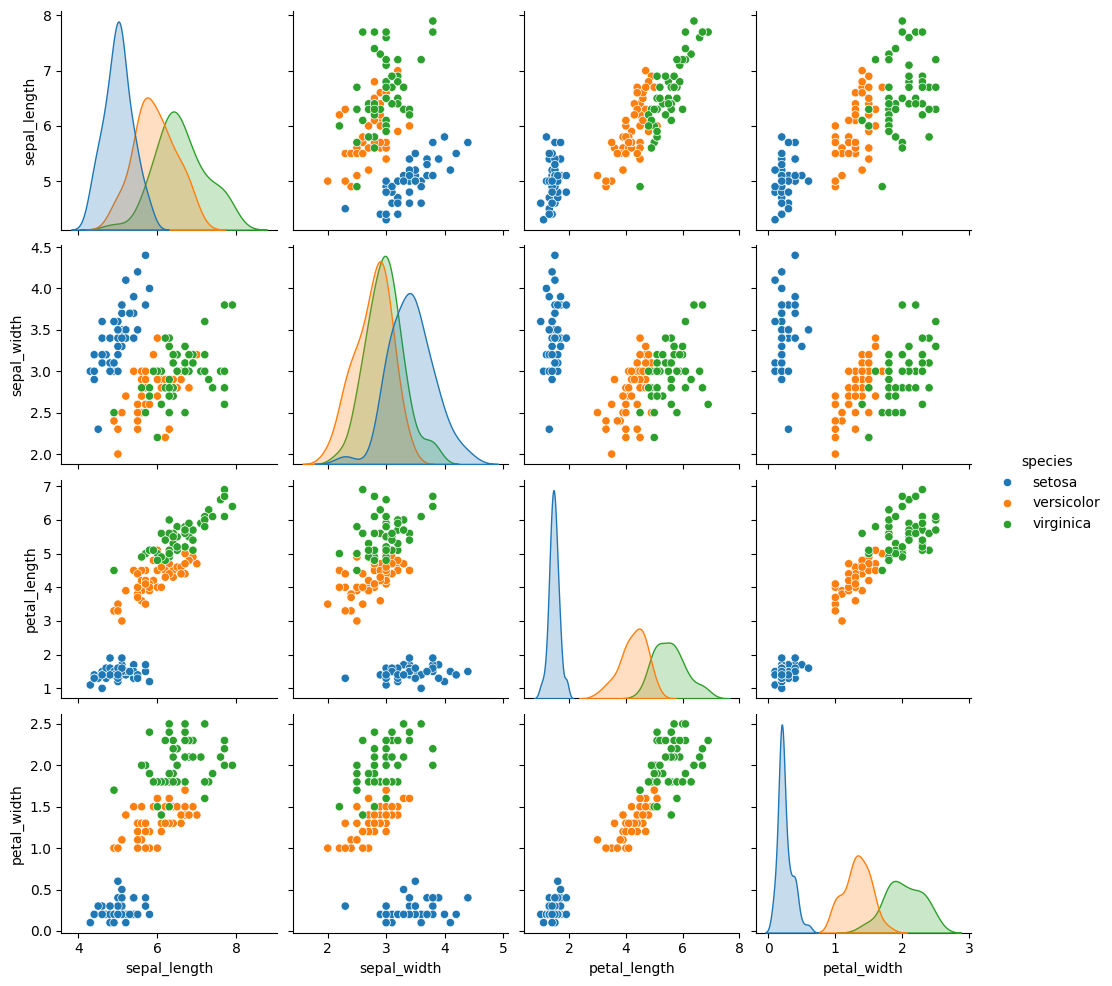

In [8]:
sns.pairplot(df, hue="species")
plt.show()

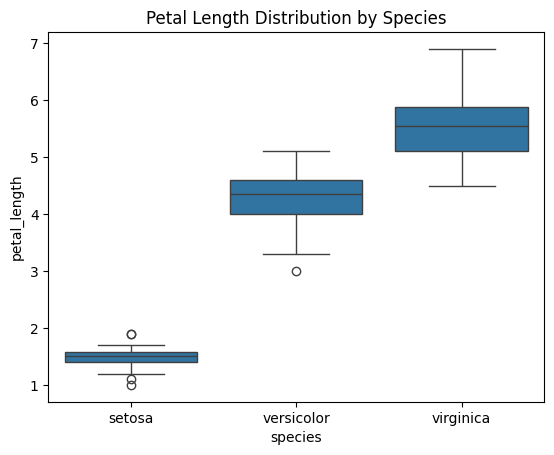

In [9]:
sns.boxplot(data=df, x="species", y="petal_length")
plt.title("Petal Length Distribution by Species")
plt.show()

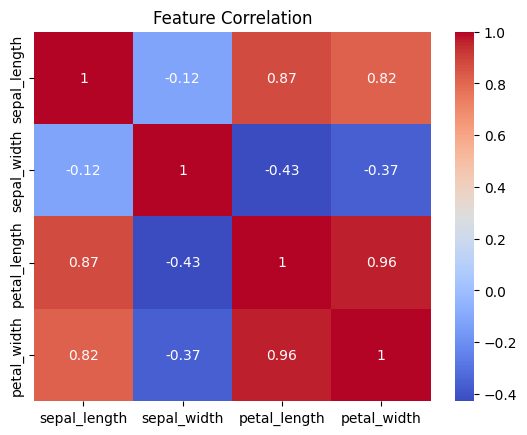

In [10]:
numeric_df = df.drop(columns="species")
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [11]:
X = df.drop("species", axis=1)
y = df["species"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (120, 4)
X_test: (30, 4)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
y_test

,species
38,setosa
127,virginica
57,versicolor
93,versicolor
42,setosa
56,versicolor
22,setosa
20,setosa
147,virginica
84,versicolor


In [14]:
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9333333333333333


In [15]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9333333333333333


In [16]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9333333333333333


In [17]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9


In [18]:
model_svm = SVC()
model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9666666666666667


,Model,Accuracy
4,SVM,0.966667
0,Logistic Regression,0.933333
1,KNN,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


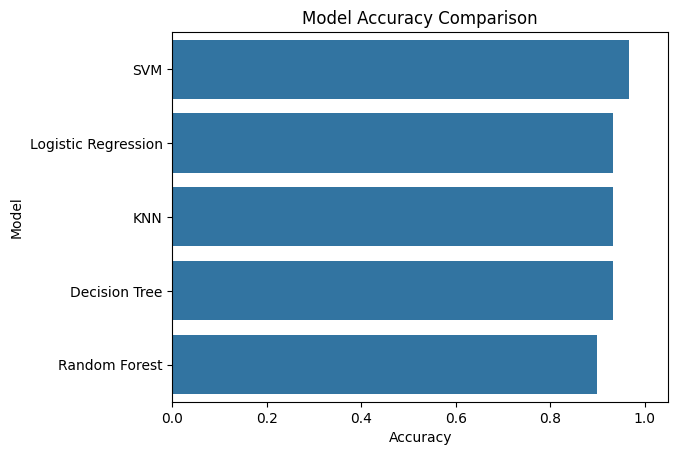

In [19]:
results = pd.DataFrame({"Model":["Logistic Regression","KNN","Decision Tree","Random Forest","SVM"],"Accuracy":[accuracy_lr,accuracy_knn,accuracy_dt,accuracy_rf,accuracy_svm]}).sort_values("Accuracy", ascending=False)
display(results)
sns.barplot(data=results, x="Accuracy", y="Model")
plt.xlim(0,1.05)
plt.title("Model Accuracy Comparison")
plt.show()

[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


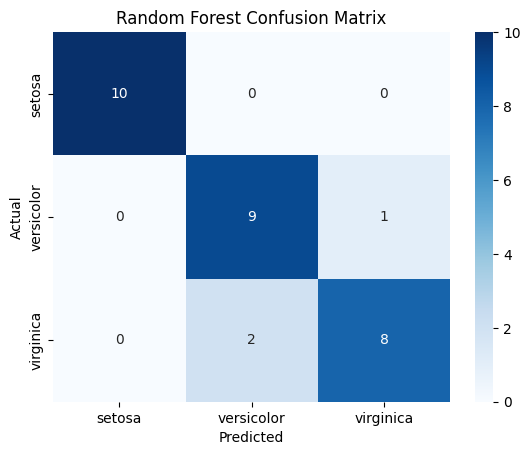

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



,Feature,Importance
3,petal_width,0.437185
2,petal_length,0.431466
0,sepal_length,0.116349
1,sepal_width,0.015000


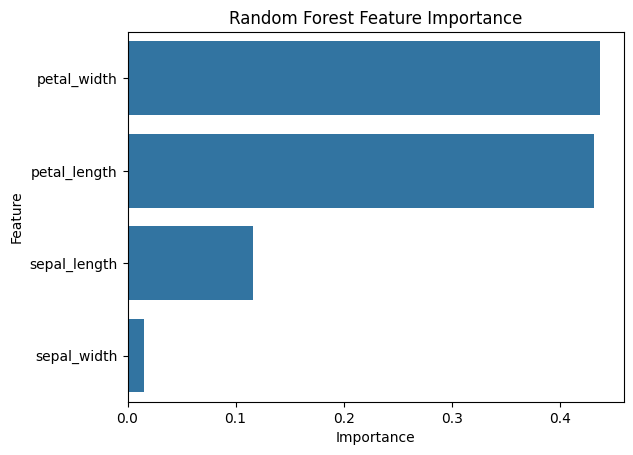

In [22]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":model_rf.feature_importances_}).sort_values("Importance", ascending=False)
display(importance)
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

In [23]:
new_flower = pd.DataFrame({"sepal_length":[5.1],"sepal_width":[3.5],"petal_length":[1.4],"petal_width":[0.2]})
prediction = model_rf.predict(new_flower)
print("New flower:")
display(new_flower)
print("Predicted species:", prediction[0])
print("Probabilities:")
display(pd.DataFrame(model_rf.predict_proba(new_flower), columns=model_rf.classes_))

New flower:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


Predicted species: setosa
Probabilities:


,setosa,versicolor,virginica
0,1.0,0.0,0.0


# Practice Exercises

1. Change test_size to 0.30.
2. Try KNN with n_neighbors=3, 7, and 10.
3. Change Random Forest n_estimators to 200.
4. Create a confusion matrix for Logistic Regression.
5. Compare precision, recall, and F1-score for all models.
6. Predict your own flower measurements.